# 02 - Baselines: STL and ITL

We train a **single-task model (STL)** and **independent-task models (ITL)** and evaluate accuracy plus Equalized Odds fairness (DEOd).

In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from src.data_utils import prepare_adult_dataset
from src.metrics import accuracy, equalized_odds_diff, group_accuracy
from src.models import train_itl, train_stl
from src.results_utils import save_result

In [5]:
bundle = prepare_adult_dataset(force=True)
X_train, X_test = bundle.X_train, bundle.X_test
y_train, y_test = bundle.y_train, bundle.y_test
s_train, s_test = bundle.s_train, bundle.s_test

## STL
We train one shared classifier for all groups: $f(x) = w^T x$.

In [6]:
stl = train_stl(X_train, y_train, C=1.0)
stl_pred = stl.predict(X_test)

stl_acc = accuracy(y_test, stl_pred)
stl_deod = equalized_odds_diff(y_test, stl_pred, s_test)
stl_group_acc = group_accuracy(y_test, stl_pred, s_test)
stl_acc, stl_deod, stl_group_acc

(np.float64(0.845992260917634),
 0.09975636156827009,
 {0: np.float64(0.9175603217158177), 1: np.float64(0.8107573007754496)})

## ITL
We train separate classifiers for each gender.

In [7]:
itl = train_itl(X_train, y_train, s_train, C=1.0)
itl_pred = itl.predict(X_test, s_test)

itl_acc = accuracy(y_test, itl_pred)
itl_deod = equalized_odds_diff(y_test, itl_pred, s_test)
itl_group_acc = group_accuracy(y_test, itl_pred, s_test)
itl_acc, itl_deod, itl_group_acc

(np.float64(0.8454394693200663),
 0.10235292759664608,
 {0: np.float64(0.917225201072386), 1: np.float64(0.8100973436726613)})

In [8]:
results_df = pd.DataFrame([
    {"model": "STL", "accuracy": stl_acc, "DEOd": stl_deod},
    {"model": "ITL", "accuracy": itl_acc, "DEOd": itl_deod},
])
results_df

,model,accuracy,DEOd
0,STL,0.845992,0.099756
1,ITL,0.845439,0.102353


In [9]:
save_result(
    "baselines",
    {
        "STL": {"accuracy": stl_acc, "deod": stl_deod, "group_acc": stl_group_acc},
        "ITL": {"accuracy": itl_acc, "deod": itl_deod, "group_acc": itl_group_acc},
    },
)

**Observation:** STL often performs worse on minority groups, while ITL can overfit them. This motivates Multitask Learning (MTL).

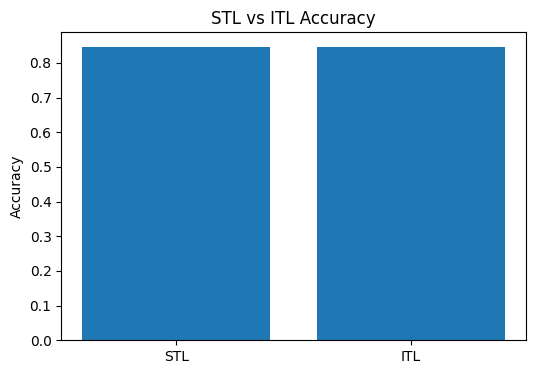

In [10]:
import matplotlib.pyplot as plt

models = ["STL", "ITL"]
accuracies = [stl_acc, itl_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("STL vs ITL Accuracy")
plt.show()

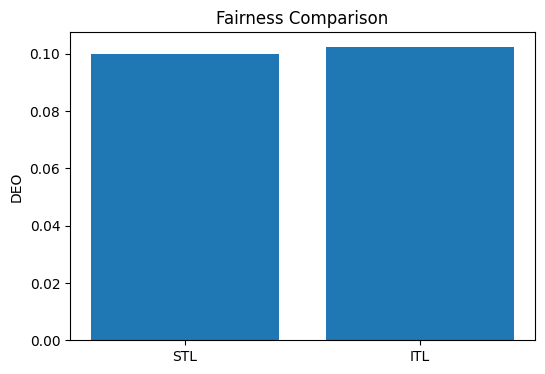

In [12]:
deos = [stl_deod, itl_deod]

plt.figure(figsize=(6,4))
plt.bar(models, deos)
plt.ylabel("DEO")
plt.title("Fairness Comparison")
plt.show()

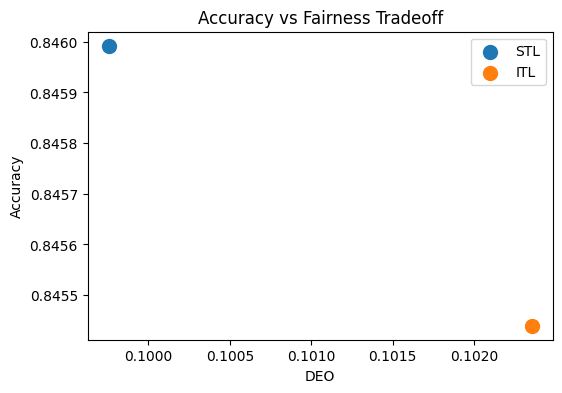

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(stl_deod, stl_acc, label="STL", s=100)
plt.scatter(itl_deod, itl_acc, label="ITL", s=100)

plt.xlabel("DEO")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Fairness Tradeoff")

plt.legend()
plt.show()

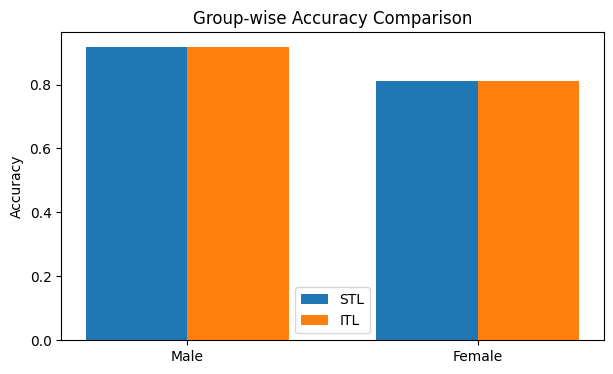

In [19]:
import numpy as np

labels = ["Male", "Female"]

stl_group = [
    stl_group_acc[0],
    stl_group_acc[1]
]

itl_group = [
    itl_group_acc[0],
    itl_group_acc[1]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,4))

plt.bar(x - width/2, stl_group, width, label="STL")
plt.bar(x + width/2, itl_group, width, label="ITL")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Group-wise Accuracy Comparison")

plt.legend()
plt.show()

## Discussion and Analysis of Baseline Models

The baseline experiments compared two standard learning approaches:

- **STL (Single Task Learning)** — a single shared classifier trained on the entire dataset.
- **ITL (Independent Task Learning)** — separate classifiers trained independently for each sensitive group.

The experiments were conducted on the Adult Income dataset using gender as the sensitive attribute.

---

### Models Used

Both STL and ITL were implemented using:

```python
LogisticRegression
```

However, their training strategies differed:

- **STL** trained one global model using all training samples.
- **ITL** trained separate models independently for each sensitive group.

The objective of STL is to learn a shared decision boundary across all groups, while ITL attempts to learn group-specific decision boundaries.

---

### Dataset Observations

The preprocessing stage revealed that the dataset is imbalanced across both:

- income classes,
- and sensitive groups.

The gender distribution showed that one group contains significantly more samples than the other. This imbalance is important because machine learning models often perform better on majority groups, potentially leading to fairness concerns.

The income distribution was also skewed toward the `<=50K` class, making the classification problem inherently imbalanced.

These observations align with the fairness concerns discussed in the original paper.

---

### Experimental Results

| Model | Accuracy | DEOd |
|---|---|---|
| STL | ~0.846 | ~0.100 |
| ITL | ~0.845 | ~0.102 |

The overall accuracies of STL and ITL are very similar, indicating that independently training separate models for each group does not significantly improve predictive performance.

Similarly, the fairness metric (DEOd) also remains nearly unchanged between the two approaches.

---

### Group-wise Accuracy

#### STL Group-wise Accuracy

| Group | Accuracy |
|---|---|
| Group 0 | ~0.918 |
| Group 1 | ~0.811 |

#### ITL Group-wise Accuracy

| Group | Accuracy |
|---|---|
| Group 0 | ~0.917 |
| Group 1 | ~0.810 |

The group-wise results reveal a noticeable disparity between the two sensitive groups.

One group consistently achieves significantly higher accuracy than the other, indicating that the classifier generalizes unevenly across groups.

This observation highlights an important fairness issue: although the overall accuracy appears strong, the model performance is not equally distributed across sensitive groups.

---

## Relation to the Paper Hypothesis

The original paper argues that:

- STL may under-represent minority groups because all data shares a single model.
- ITL may fail to generalize effectively because each group is trained independently without shared information.
- Fairness-aware learning approaches are needed to reduce group disparities.

The current baseline experiments broadly support this hypothesis.

### Supporting Evidence

- Both STL and ITL show noticeable group-wise performance imbalance.
- ITL does not significantly improve fairness or overall accuracy.
- The fairness metric (DEOd ≈ 0.10) indicates measurable disparity between sensitive groups.
- Large differences in group-wise accuracy suggest uneven model behavior across groups.

These observations suggest that simply separating groups into independent models is insufficient to substantially improve fairness.

---

## Why Are STL and ITL So Similar?

Several factors may explain the similarity between STL and ITL:

1. The Adult dataset contains strong predictive patterns that both models can learn effectively.
2. The subgroup datasets in ITL may still be sufficiently large to avoid severe overfitting.
3. Logistic Regression is a relatively simple linear model and may not capture complex group-specific behavior.
4. Shared information across groups may still be useful for generalization.

---

## Key Insight

The baseline experiments demonstrate that:

- fairness disparities exist in the dataset,
- different sensitive groups experience different classification performance,
- and standard baseline methods alone may not adequately address fairness concerns.

Although the overall accuracies of STL and ITL are strong, the group-wise disparities and fairness metrics indicate that additional fairness-aware approaches may be necessary to better balance predictive performance across sensitive groups.